In [1]:
import matplotlib.pyplot as plt, numpy as np, seaborn as sns, scipy.stats as stats, pandas as pd, os, glob
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from scipy.stats import rankdata
from scipy.stats import ttest_ind

In [2]:
df_clean = pd.read_csv('../../results/psychopy/all_subjs_clean.csv')
patients = df_clean['subj'].unique().tolist()
print(patients)
n_pts = len(patients)
df_clean

[9, 11, 12, 18, 21, 22]


,dir_flip,sess_flip,chosen_pos_aligned,div_pos_aligned,stim_pos,true_class,pred_class,err_type,invalid,incomplete,...,frameRate,expStart,Unnamed: 119,chosen_pos,Unnamed: 112,stim_ranks,resp_ranks,stim_ranks_aligned,resp_ranks_aligned,block_name
0,1.0,NaN,-0.044,-0.0,0.02,1,0,-1,False,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.044,NaN,42.5,23.5,3.25,-15.75,baseline_1.0
1,1.0,NaN,0.040,-0.0,0.38,1,1,0,False,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,-0.040,NaN,78.5,49.0,39.25,9.75,baseline_1.0
2,0.0,NaN,-0.044,0.0,-0.02,0,0,0,False,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,-0.044,NaN,38.5,23.5,-0.75,-15.75,baseline_1.0
3,1.0,NaN,-0.068,-0.0,0.06,1,0,-1,False,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.068,NaN,46.5,13.5,7.25,-25.75,baseline_1.0
4,0.0,NaN,0.008,0.0,0.38,1,1,0,False,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.008,NaN,78.5,36.0,39.25,-3.25,baseline_1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,1.0,NaN,0.296,0.2,0.22,0,1,1,False,False,...,60.0,2026-01-01 16h46.37.833115 -0700,NaN,-0.296,NaN,44.5,48.0,5.25,8.75,flat_comp_1.0
1436,0.0,NaN,-0.160,0.2,-0.10,1,0,-1,False,False,...,60.0,2026-01-01 16h46.37.833115 -0700,NaN,-0.160,NaN,10.5,18.5,-28.75,-20.75,flat_comp_1.0
1437,0.0,NaN,0.396,0.2,0.30,0,1,1,False,False,...,60.0,2026-01-01 16h46.37.833115 -0700,NaN,0.396,NaN,60.5,74.5,21.25,35.25,flat_comp_1.0
1438,0.0,NaN,0.344,0.2,0.38,0,1,1,False,False,...,60.0,2026-01-01 16h46.37.833115 -0700,NaN,0.344,NaN,76.5,60.5,37.25,21.25,flat_comp_1.0


### setup

In [3]:
df_curv = df_clean[df_clean['condition'] == 'curv_comp'].copy()
df_base = df_clean[df_clean['condition'] == 'baseline'].copy()
df_flat = df_clean[df_clean['condition'] == 'flat_comp'].copy()

print(len(df_curv), len(df_base), len(df_flat))

480 480 480


In [4]:
# choose what df
def get_df(df_name):
    if df_name == 'base':
        return df_name, df_base
    elif df_name == 'curv':
        return df_name, df_curv
    elif df_name == 'flat':
        return df_name, df_flat

### timing checks

In [5]:
# # choose what youre plotting
# ptID = 9
# df_analysis = df_clean[df_clean['subj'] == ptID].copy().reset_index(drop=True)
# # df_analysis = df_clean.copy()
# print(f'len(df): {len(df_analysis)}')

# # create column for each phases's duration
# expt_phases = ['baseline', 'stim', 'delay', 'task', 'anticipation', 'feedback']
# for phase in expt_phases:
#     df_analysis[f'{phase}_dur'] = df_analysis[f'{phase}.stopped'] - df_analysis[f'{phase}.started']

# # sid, check if these are needed replacements
# df_analysis['stim_dur'] = df_analysis['stim.stopped'] - df_analysis['target_stim.started']
# df_analysis['feedback_dur'] = df_analysis['feedback.stopped'] - df_analysis['no_resp_text.started']

# fig, axs = plt.subplots(2, 3, figsize=(15, 4))
# axs, ax = axs.flatten(), 0

# for expt_phase in expt_phases:

#     sns.histplot(df_analysis[f'{expt_phase}_dur'], bins=20, kde=True, ax=axs[ax])
#     axs[ax].set(title=expt_phase, xlabel='', ylabel='Count')
#     ax += 1

# plt.suptitle(f'Task Durations', fontsize=16)
# plt.tight_layout()
# plt.show()

### error trials

In [6]:
# choose what youre plotting
ptID = 9
df_analysis = df_clean[df_clean['subj'] == ptID].copy().reset_index(drop=True)
df_analysis = df_clean.copy()
print(f'len(df): {len(df_analysis)}')

num_incomplete = df_analysis['incomplete'].sum()
num_invalid = df_analysis['invalid'].sum()
num_incorrect = df_analysis['incorrect'].sum()
print(f'\
incomplete: {num_incomplete} ({num_incomplete / 240 * 100:.2f}%),\
 invalid: {num_invalid} ({num_invalid / 240 * 100:.2f}%),\
 incorrect: {num_incorrect} ({num_incorrect / 240 * 100:.2f}%)')

# proportion correct
prop_correct = df_analysis['correct'].mean()
print(f'Proportion correct: {prop_correct:.2f}')

# pearson and spearman correlations between stim_pos and chosen_pos_aligned
pearson_corr = df_analysis['stim_pos'].corr(df_analysis['chosen_pos_aligned'], method='pearson')
spearman_corr = df_analysis['stim_pos'].corr(df_analysis['chosen_pos_aligned'], method='spearman')
print(f'Pearson correlation: {pearson_corr:.2f}')
print(f'Spearman correlation: {spearman_corr:.2f}')

# ensure this is the same
pearson_corr = df_analysis['target_pos'].corr(df_analysis['chosen_pos'], method='pearson')
spearman_corr = df_analysis['target_pos'].corr(df_analysis['chosen_pos'], method='spearman')


len(df): 1440
incomplete: 36 (15.00%), invalid: 30 (12.50%), incorrect: 248 (103.33%)
Proportion correct: 0.79
Pearson correlation: 0.70
Spearman correlation: 0.71


### plot setup

In [7]:
norm_ticks, norm_ticklabels = np.linspace(-.4, .4, 5), np.linspace(0, 1, 5)

### response distribution

In [8]:

# fig, axs = plt.subplots(1, 3, figsize=(12, 3))
# axs, ax = axs.flatten(), 0

# ba_bins = np.linspace(-.4, .4, 21)
# bar_centers = np.linspace(-.38, .38, 20)

# for cond in ['curv_comp', 'baseline', 'flat_comp']: # ordered

#     df_cond = df_analysis[df_analysis['condition'] == cond].copy()

#     # true stim distribution per subj (stim_pos is already in -.4 to .4 space)
#     stim_cts = []
#     for subj, subj_df in df_cond.groupby('subj'):
#         counts, _ = np.histogram(subj_df['stim_pos'], bins=ba_bins)
#         stim_cts.append(counts)
#     stim_cts = np.array(stim_cts)
#     mean_stim_cts = stim_cts.mean(axis=0)

#     # response distribution per subj
#     resp_cts = []
#     for subj, subj_df in df_cond.groupby('subj'):
#         counts, _ = np.histogram(subj_df['chosen_pos_aligned'], bins=ba_bins)
#         resp_cts.append(counts)
#     resp_cts = np.array(resp_cts)
#     mean_resp_cts = resp_cts.mean(axis=0)
#     sem_resp_cts = resp_cts.std(axis=0) / np.sqrt(resp_cts.shape[0])

#     # plot
#     axs[ax].bar(bar_centers, mean_stim_cts, width=.04, color='green', alpha=0.7, label='stim')
#     axs[ax].bar(bar_centers, mean_resp_cts, width=.04, color='deepskyblue',
#                 yerr=sem_resp_cts, capsize=3, label='response', alpha=0.6)

#     axs[ax].set(xlabel='position', ylabel='count', xlim=(-.4, .4), ylim=(0,20),
#                 xticks=norm_ticks, xticklabels=norm_ticklabels)
#     # boundary
#     axs[ax].axvline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='--')
#     axs[ax].legend(fontsize=8)
#     ax += 1

# plt.suptitle(f'Patients (n={df_analysis["subj"].nunique()})', fontsize=16)
# plt.tight_layout()
# plt.show()


## stim vs resp

### raw

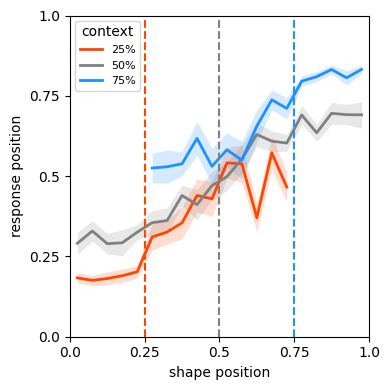

In [9]:
# plot stim vs resp, colored by condition (mean ± SEM)
fig, ax = plt.subplots(1, 1, figsize=(4,4))
colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
cond_label_map = {'curv_comp': '25%', 'baseline': '50%', 'flat_comp': '75%'}

for cond in ['curv_comp', 'baseline', 'flat_comp']:
    df_cond = df_clean[df_clean['condition'] == cond].copy()
    # Compute mean and SEM for each stim_pos
    grouped = df_cond.groupby('stim_pos')['chosen_pos_aligned']
    mean_resp = grouped.mean().sort_index()
    sem_resp = grouped.sem().sort_index()
    x = mean_resp.index.values
    y = mean_resp.values
    yerr = sem_resp.values
    # Plot mean line
    ax.plot(x, y, '-', linewidth=2, label=cond_label_map[cond], color=colors[cond])
    # Plot SEM band
    ax.fill_between(x, y - yerr, y + yerr, color=colors[cond], alpha=0.18, linewidth=0)

# add identity line
# ax.plot([-.4, .4], [-.4, .4], 'k--', alpha=0.3)
ax.axvline(-0.2, color='orangered', linewidth=1.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=1.5, linestyle='--')
ax.axvline(0.2, color='dodgerblue', linewidth=1.5, linestyle='--')

ax.set(xlabel='shape position', ylabel='response position',
       xticks=norm_ticks, xticklabels=norm_ticklabels,
       yticks=norm_ticks, yticklabels=norm_ticklabels,
       xlim=(-.4, .4), ylim=(-.4, .4))

ax.legend(fontsize=8, title='context')
plt.tight_layout()
plt.show()


### boundary-aligned

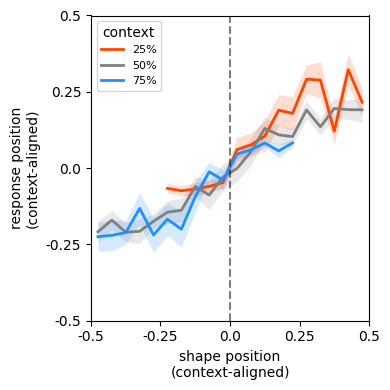

In [10]:
# plot stim vs resp, colored by condition (mean ± SEM)
fig, ax = plt.subplots(1, 1, figsize=(4,4))
colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
cond_label_map = {'curv_comp': '25%', 'baseline': '50%', 'flat_comp': '75%'}

for cond in ['curv_comp', 'baseline', 'flat_comp']:
    df_cond = df_clean[df_clean['condition'] == cond].copy()
    grouped = df_cond.groupby('stim_aligned_to_div')['resp_aligned_to_div']
    mean_resp = grouped.mean().sort_index()
    sem_resp = grouped.sem().sort_index()
    x = mean_resp.index.values
    y = mean_resp.values
    yerr = sem_resp.values
    ax.plot(x, y, '-', linewidth=2, label=cond_label_map[cond], color=colors[cond])
    ax.fill_between(x, y - yerr, y + yerr, color=colors[cond], alpha=0.18, linewidth=0)

ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
ba_ticklabels = np.linspace(-.5, .5, 5)
ax.set(xlabel='shape position\n(context-aligned)', ylabel='response position\n(context-aligned)',
       xticks=norm_ticks, xticklabels=ba_ticklabels,
       yticks=norm_ticks, yticklabels=ba_ticklabels,
       xlim=(-.4, .4), ylim=(-.4, .4))

ax.legend(fontsize=8, title='context')
plt.tight_layout()
plt.show()


### rank-aligned

In [11]:
# # plot stim vs resp, colored by condition (mean ± SEM)
# fig, ax = plt.subplots(1, 1, figsize=(4,4))
# colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
# cond_label_map = {'curv_comp': '25%', 'baseline': '50%', 'flat_comp': '75%'}

# for cond in ['curv_comp', 'baseline', 'flat_comp']:
#     df_cond = df_clean[df_clean['condition'] == cond].copy()
#     grouped = df_cond.groupby('stim_ranks')['resp_ranks']
#     mean_resp = grouped.mean().sort_index()
#     sem_resp = grouped.sem().sort_index()
#     x = mean_resp.index.values
#     y = mean_resp.values
#     yerr = sem_resp.values
#     ax.plot(x, y, '-', linewidth=2, label=cond_label_map[cond], color=colors[cond])
#     ax.fill_between(x, y - yerr, y + yerr, color=colors[cond], alpha=0.18, linewidth=0)

# ax.axvline(40, color='black', linewidth=1.5, linestyle='--')
# ax.set(xlabel='stim rank', ylabel='resp rank')
# ax.legend(fontsize=8, title='context')
# plt.tight_layout()
# plt.show()


### visualizing reflection of compressed conditions

In [12]:
# # plot stim vs resp, colored by condition (mean ± SEM)
# fig, ax = plt.subplots(1, 1, figsize=(4,4))
# colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
# cond_label_map = {'curv_comp': '25%', 'baseline': '50%', 'flat_comp': '75%'}

# for cond in ['curv_comp', 'baseline', 'flat_comp']:
#     df_cond = df_clean[df_clean['condition'] == cond].copy()
#     if cond == 'flat_comp':
#         df_cond['stim_aligned_to_div'] = -df_cond['stim_aligned_to_div']
#         df_cond['resp_aligned_to_div'] = -df_cond['resp_aligned_to_div']
#     grouped = df_cond.groupby('stim_aligned_to_div')['resp_aligned_to_div']
#     mean_resp = grouped.mean().sort_index()
#     sem_resp = grouped.sem().sort_index()
#     x = mean_resp.index.values
#     y = mean_resp.values
#     yerr = sem_resp.values
#     ax.plot(x, y, '-', linewidth=2, label=cond_label_map[cond], color=colors[cond])
#     ax.fill_between(x, y - yerr, y + yerr, color=colors[cond], alpha=0.18, linewidth=0)

# # add identity line
# # ax.plot([-.4, .4], [-.4, .4], 'k--', alpha=0.3)
# ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
# ax.set(xlabel='shape position\n(baseline-reflected)', ylabel='response position\n(baseline-reflected)',
#        xticks=norm_ticks, xticklabels=norm_ticklabels,
#        yticks=norm_ticks, yticklabels=norm_ticklabels,
#        xlim=(-.4, .4), ylim=(-.4, .4))

# ax.legend(fontsize=8, title='context')
# plt.tight_layout()
# plt.show()


### sigfig testing

In [13]:
# Flip flat_comp to align with baseline, and reverse for spatial ordering

def compute_mse(arr1, arr2):
    """Compute MSE using minimum length for alignment (handles different condition lengths)"""
    min_len = min(len(arr1), len(arr2))
    return np.mean((arr1[:min_len] - arr2[:min_len]) ** 2)

conditions = ['curv_comp', 'baseline', 'flat_comp']
mse_results = []

for subj in patients:
    subj_mask = df_clean['subj'] == subj
    cond_vecs = {}
    
    for cond in conditions:
        mask = subj_mask & (df_clean['condition'] == cond)
        subj_cond_data = df_clean[mask]
        
        # Group by stim value and average responses
        grouped = subj_cond_data.groupby('stim_aligned_to_div', as_index=False)['resp_aligned_to_div'].mean()
        
        stim_vec = grouped['stim_aligned_to_div'].values
        resp_vec = grouped['resp_aligned_to_div'].values
        
        cond_vecs[cond] = {'stim': stim_vec, 'resp': resp_vec}
    
    # Flip flat_comp stim and resp (negate and reverse for spatial alignment)
    cond_vecs['flat_comp']['stim'] = -cond_vecs['flat_comp']['stim'][::-1]
    cond_vecs['flat_comp']['resp'] = -cond_vecs['flat_comp']['resp'][::-1]
    
    # Within-condition MSEs (stim vs resp)
    mse_result = {
        'subj': subj,
        'curv_within': compute_mse(cond_vecs['curv_comp']['stim'], cond_vecs['curv_comp']['resp']),
        'base_within': compute_mse(cond_vecs['baseline']['stim'], cond_vecs['baseline']['resp']),
        'flat_within': compute_mse(cond_vecs['flat_comp']['stim'], cond_vecs['flat_comp']['resp']),
    }
    
    # Pairwise MSEs (resp vs resp) - NO normalization
    curv_resp = cond_vecs['curv_comp']['resp']
    base_resp = cond_vecs['baseline']['resp']
    flat_resp = cond_vecs['flat_comp']['resp']
    
    mse_result['curv_vs_base'] = compute_mse(curv_resp, base_resp)
    mse_result['curv_vs_flat'] = compute_mse(curv_resp, flat_resp)
    mse_result['base_vs_flat'] = compute_mse(base_resp, flat_resp)
    
    mse_results.append(mse_result)

mse_df = pd.DataFrame(mse_results)
print("MSE (flat_comp flipped+reversed, no normalization):")
print(mse_df)


MSE (flat_comp flipped+reversed, no normalization):
   subj  curv_within  base_within  flat_within  curv_vs_base  curv_vs_flat  \
0     9     0.021446     0.030542     0.014437      0.004890      0.001975   
1    11     0.013014     0.019361     0.024226      0.038164      0.020758   
2    12     0.013902     0.010382     0.013919      0.095966      0.018600   
3    18     0.022891     0.032065     0.026302      0.003368      0.001507   
4    21     0.021398     0.024286     0.026615      0.006942      0.003035   
5    22     0.020637     0.010820     0.012686      0.096643      0.018884   

   base_vs_flat  
0      0.004959  
1      0.011778  
2      0.079408  
3      0.002604  
4      0.006223  
5      0.105860  


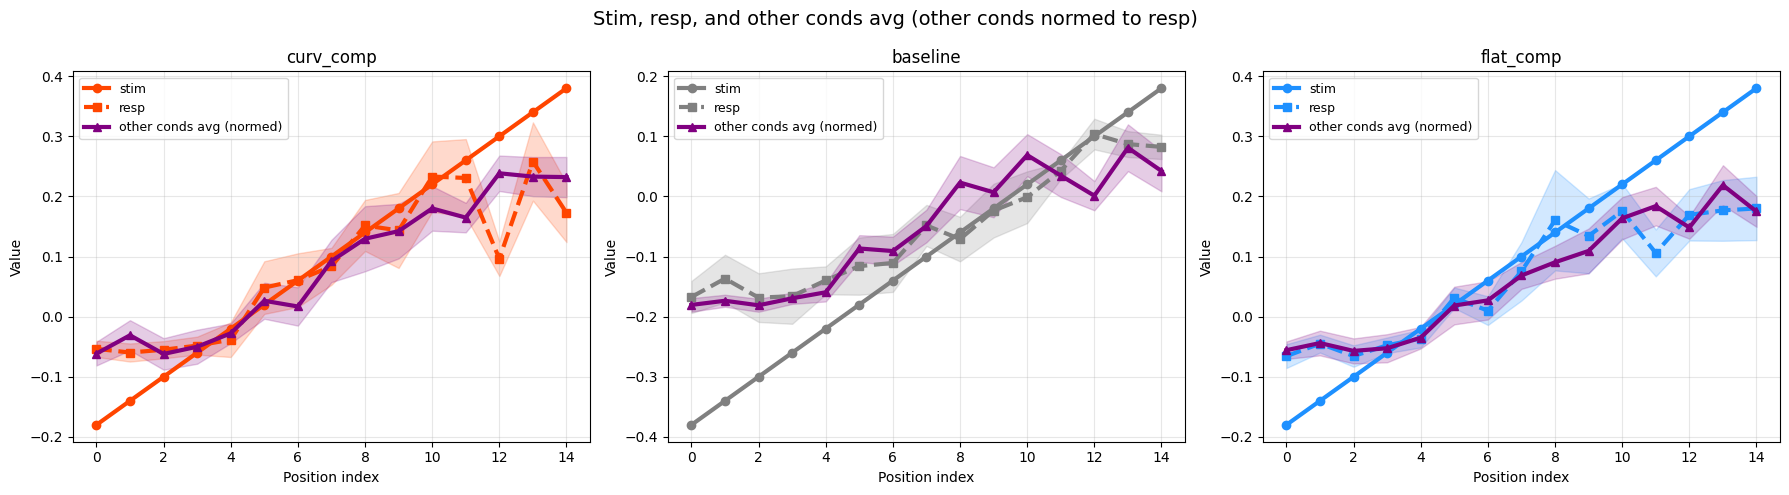

In [14]:
# Visualize stim, resp, and other conds avg for each condition (no top row)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
colors_cond = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
other_color = 'purple'

cond_vecs_all = {}
for cond in conditions:
    stim_vecs = []
    resp_vecs = []
    for subj in patients:
        subj_mask = df_clean['subj'] == subj
        mask = subj_mask & (df_clean['condition'] == cond)
        subj_cond_data = df_clean[mask]
        grouped = subj_cond_data.groupby('stim_aligned_to_div', as_index=False)['resp_aligned_to_div'].mean()
        stim = grouped['stim_aligned_to_div'].values
        resp = grouped['resp_aligned_to_div'].values
        stim_vecs.append(stim)
        resp_vecs.append(resp)
    stim_stack = np.array(stim_vecs)
    resp_stack = np.array(resp_vecs)
    if cond == 'flat_comp':
        stim_stack = -stim_stack[:, ::-1]
        resp_stack = -resp_stack[:, ::-1]
    cond_vecs_all[cond] = {
        'stim_mean': stim_stack.mean(axis=0),
        'stim_sem': stim_stack.std(axis=0) / np.sqrt(stim_stack.shape[0]),
        'resp_mean': resp_stack.mean(axis=0),
        'resp_sem': resp_stack.std(axis=0) / np.sqrt(resp_stack.shape[0]),
        'x_idx': np.arange(len(stim_stack[0]))
    }

# For each plot: show stim, resp for that cond, and avg of other conds (other conds avg normalized to this cond's resp)
for cond_idx, cond in enumerate(conditions):
    ax = axs[cond_idx]
    # Get other two conditions
    other_conds = [c for c in conditions if c != cond]
    # Find common length for all three
    common_len = min(len(cond_vecs_all[cond]['resp_mean']), *(len(cond_vecs_all[c]['resp_mean']) for c in other_conds))
    x_idx = cond_vecs_all[cond]['x_idx'][:common_len]
    # Main resp and stim
    resp = cond_vecs_all[cond]['resp_mean'][:common_len]
    resp_sem = cond_vecs_all[cond]['resp_sem'][:common_len]
    stim = cond_vecs_all[cond]['stim_mean'][:common_len]
    stim_sem = cond_vecs_all[cond]['stim_sem'][:common_len]
    # Other conds' avg (normalize to this cond's resp)
    other_resp = np.mean([cond_vecs_all[c]['resp_mean'][:common_len] for c in other_conds], axis=0)
    other_sem = np.sqrt(np.sum([cond_vecs_all[c]['resp_sem'][:common_len]**2 for c in other_conds], axis=0)) / len(other_conds)
    # Normalize other_resp and other_sem to this cond's resp
    resp_mean = resp.mean()
    resp_std = resp.std() + 1e-10
    other_resp_norm = (other_resp - other_resp.mean()) / (other_resp.std() + 1e-10) * resp_std + resp_mean
    other_sem_norm = other_sem / (other_resp.std() + 1e-10) * resp_std
    # Plot
    ax.plot(x_idx, stim, 'o-', color=colors_cond[cond], linewidth=3, label='stim')
    ax.fill_between(x_idx, stim - stim_sem, stim + stim_sem, color=colors_cond[cond], alpha=0.2)
    ax.plot(x_idx, resp, 's--', color=colors_cond[cond], linewidth=3, label='resp')
    ax.fill_between(x_idx, resp - resp_sem, resp + resp_sem, color=colors_cond[cond], alpha=0.2)
    ax.plot(x_idx, other_resp_norm, '^-', color=other_color, linewidth=3, label='other conds avg (normed)')
    ax.fill_between(x_idx, other_resp_norm - other_sem_norm, other_resp_norm + other_sem_norm, color=other_color, alpha=0.2)
    ax.set(xlabel='Position index', ylabel='Value', title=f'{cond}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
plt.suptitle('Stim, resp, and other conds avg (other conds normed to resp)', fontsize=14)
plt.tight_layout()
plt.show()


In [15]:
# Compute and print stats for normed version (resp vs normed other conds avg)
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon

def compute_mse(arr1, arr2):
    min_len = min(len(arr1), len(arr2))
    return np.mean((arr1[:min_len] - arr2[:min_len]) ** 2)

mse_within = []
mse_across_normed = []

for subj in patients:
    subj_mask = df_clean['subj'] == subj
    cond_vecs = {}
    for cond in conditions:
        mask = subj_mask & (df_clean['condition'] == cond)
        subj_cond_data = df_clean[mask]
        grouped = subj_cond_data.groupby('stim_aligned_to_div', as_index=False)['resp_aligned_to_div'].mean()
        stim_vec = grouped['stim_aligned_to_div'].values
        resp_vec = grouped['resp_aligned_to_div'].values
        cond_vecs[cond] = {'stim': stim_vec, 'resp': resp_vec}
    # Flip flat_comp
    cond_vecs['flat_comp']['stim'] = -cond_vecs['flat_comp']['stim'][::-1]
    cond_vecs['flat_comp']['resp'] = -cond_vecs['flat_comp']['resp'][::-1]
    # For each condition, compute MSEs
    for cond in conditions:
        resp = cond_vecs[cond]['resp']
        stim = cond_vecs[cond]['stim']
        other_conds = [c for c in conditions if c != cond]
        other_resps = [cond_vecs[c]['resp'] for c in other_conds]
        common_len = min(len(resp), *(len(r) for r in other_resps))
        resp = resp[:common_len]
        stim = stim[:common_len]
        other_resps = [r[:common_len] for r in other_resps]
        other_resp = np.mean(other_resps, axis=0)
        resp_mean = resp.mean()
        resp_std = resp.std() + 1e-10
        other_resp_norm = (other_resp - other_resp.mean()) / (other_resp.std() + 1e-10) * resp_std + resp_mean
        mse_within.append(compute_mse(stim, resp))
        mse_across_normed.append(compute_mse(resp, other_resp_norm))

mse_within = np.array(mse_within)
mse_across_normed = np.array(mse_across_normed)

print(f"Within mean = {mse_within.mean():.4f} ± {mse_within.std(ddof=1):.4f}")
print(f"Across_normed mean = {mse_across_normed.mean():.4f} ± {mse_across_normed.std(ddof=1):.4f}")
t_stat, p_t = ttest_rel(mse_within, mse_across_normed)
w_stat, p_w = wilcoxon(mse_within, mse_across_normed)
print(f"Paired t: t = {t_stat:.3f}, p = {p_t:.4f}")
print(f"Wilcoxon: W = {w_stat:.1f}, p = {p_w:.4f}")


Within mean = 0.0185 ± 0.0053
Across_normed mean = 0.0079 ± 0.0085
Paired t: t = 3.614, p = 0.0021
Wilcoxon: W = 21.0, p = 0.0034


In [16]:
# fig, axs = plt.subplots(1, 3, figsize=(12, 3))
# axs, ax = axs.flatten(), 0

# # groupby condition
# for cond in ['curv_comp', 'baseline', 'flat_comp']: # ordered
    
#     df_cond = df_clean[df_clean['condition'] == cond].copy()
    
#     axs[ax].plot(df_cond['stim_pos'], df_cond['resp_ranks'], 'o', markersize=3)
#     axs[ax].axvline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='--')
#     # axs[ax].axhline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='--')
            
#     axs[ax].set(title=f'{cond}', xlabel='stim position', ylabel='response rank',
#                 xticks=norm_ticks, xticklabels=norm_ticklabels)
#     ax += 1

# plt.suptitle(f'STim vs Resp Rank', y=1.05)
# plt.show()

In [17]:
# fig, axs = plt.subplots(1, 3, figsize=(12, 3))
# axs, ax = axs.flatten(), 0

# for cond in ['curv', 'base', 'flat']:

#     # get df condition
#     df_name, df_analysis = get_df(cond)

#     # compute abs. rank error
#     df_analysis['abs_rank_err'] = np.abs(df_analysis['resp_ranks'] - df_analysis['stim_ranks'])
#     # compute median abs. rank error
#     median_by_stim = df_analysis.groupby('stim_pos', as_index=False)['abs_rank_err'].median().sort_values('stim_pos')

#     axs[ax].scatter(df_analysis['stim_pos'], df_analysis['abs_rank_err'], alpha=0.5, s=20)
#     axs[ax].plot(median_by_stim['stim_pos'], median_by_stim['abs_rank_err'], color='crimson', lw=2)

#     axs[ax].axvline(df_analysis['div_pos_aligned'].iloc[0], color='black', linestyle='--')
#     axs[ax].set(title=df_name,
#                 xlabel='Stim. Pos.', xlim=(-.4, .4), xticks=norm_ticks, xticklabels=norm_ticklabels,
#                 ylabel='|Response Rank Err.|')
#     ax += 1

# plt.tight_layout()
# plt.show()